# Rendering elements as points with `as_points`

By default, `spatialdata-plot` draws each element as its full geometry: a shape
as its polygon or circle, a labels element as its filled segmentation mask.
Passing `as_points=True` to `render_shapes()` or `render_labels()` draws one dot
per element at its centroid (its geometric centre) instead. You keep where each object sits and what
colour it has, and you give up its size and outline.

This notebook covers:

- what the option looks like on real data, for shapes and for labels,
- the appearance controls that still apply (`color`, `size`, `cmap`, `palette`),
- the backend it picks and the 50000-element rule,
- what it costs, measured on the full dataset.

The data is a Xenium human breast-cancer section with 167780 cells, so the
timings reflect a real workload rather than a toy one.

## Setup

The dataset is the Xenium replicate 1 human breast-cancer sample, converted to
the SpatialData Zarr format and hosted on the scverse example-data bucket. It is
about 3.4 GB. `pooch` downloads it once and caches it, so later runs are instant.

**This notebook is not re-executed in CI, because the download is too large. Its
outputs are committed and trusted; run it locally to reproduce them.**

In [1]:
import warnings

warnings.filterwarnings("ignore")

import time

import matplotlib.pyplot as plt
import numpy as np
import pooch

import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the .pl accessor)
from spatialdata import SpatialData, bounding_box_query, rasterize

XENIUM_URL = (
    "https://s3.embl.de/spatialdata/spatialdata-sandbox/"
    "xenium_rep1_io_spatialdata_0.7.1.zip"
)
unzipped = pooch.retrieve(
    XENIUM_URL,
    known_hash=None,
    fname="xenium_rep1_io_spatialdata_0.7.1.zip",
    processor=pooch.Unzip(),
    progressbar=True,
)
zarr_path = next(p.split(".zarr")[0] + ".zarr" for p in unzipped if ".zarr" in p)
sdata = sd.read_zarr(zarr_path)
sdata

SpatialData object, with associated Zarr store: /Users/tim.treis/Library/Caches/pooch/xenium_rep1_io_spatialdata_0.7.1.zip.unzip/data.zarr
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
│     └── 'morphology_mip': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (167780, 2) (2D shapes)
│     └── 'xenium_landmarks': GeoDataFrame shape: (3, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'aligned', with elements:
        morphology_focus (Images)
    ▸ 'global', with elements:
        morphology_focus (Images), morphology_mip (Images), transcripts (Points), cell_boundaries (Shapes)

The object above holds 167780 cells. Xenium ships the cell outlines as shapes
(`cell_circles` and `cell_boundaries`) and has no labels element, so there is no
segmentation-mask raster. We build one further down by rasterizing the
boundaries, which lets us show `as_points` on labels too.

We use a small crop for the pictures, so individual cells stay visible, and the
full section for the timings.

## 1. Shapes: full geometry vs one dot per centroid

`render_shapes(..., as_points=True)` replaces each circle or polygon with a
single marker at its centroid. Only the centroid is drawn, so `outline_width`,
`outline_color` and `shape` have no effect.

332 cells in the crop


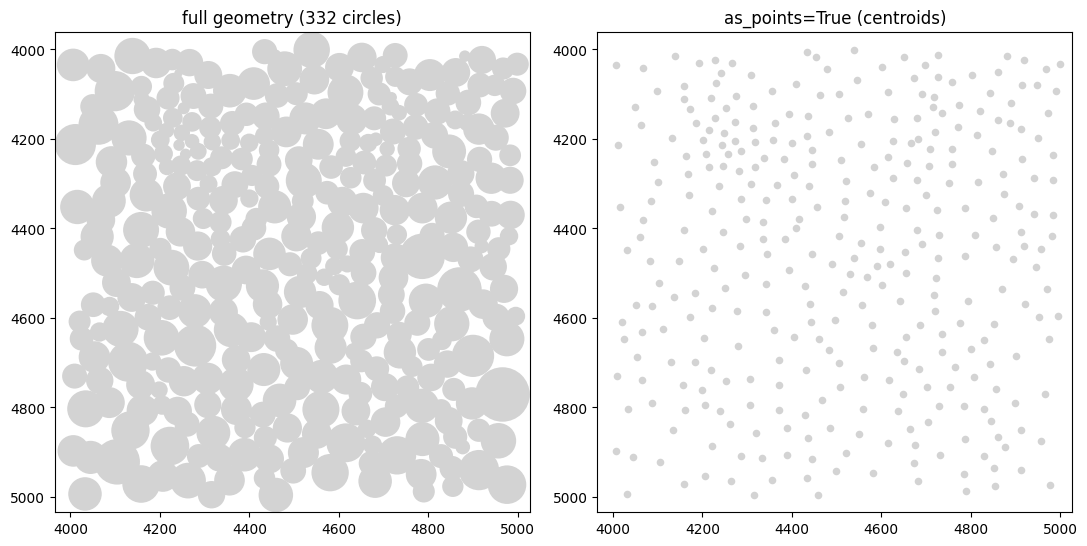

In [2]:
XMIN, YMIN, XMAX, YMAX = 4000, 4000, 5000, 5000  # a 1000 x 1000 micron window
crop = bounding_box_query(
    sdata,
    min_coordinate=[XMIN, YMIN],
    max_coordinate=[XMAX, YMAX],
    axes=("x", "y"),
    target_coordinate_system="global",
)
n_crop = len(crop["cell_circles"])
print(f"{n_crop} cells in the crop")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
crop.pl.render_shapes("cell_circles").pl.show(
    ax=axes[0], title=f"full geometry ({n_crop} circles)"
)
crop.pl.render_shapes("cell_circles", as_points=True, size=30).pl.show(
    ax=axes[1], title="as_points=True (centroids)"
)
fig.tight_layout()

## 2. Colour and size still apply

`as_points` changes what is drawn at each location, not how colour is resolved.
`color` accepts a gene name (looked up in the annotating table), a column on the
element or its table, or a literal colour. Continuous values use `cmap` and
categorical values use `palette`, exactly as for the full geometry, and legends
and colourbars behave the same way.

Here we colour by `EPCAM`, an epithelial marker. Its expression follows the
tissue: the ductal and tumour regions are bright, the surrounding stroma is dark.
The centroid view keeps that spatial trend after dropping the outlines.

The two panels below share a single colourbar only because they plot the same
`EPCAM` values. To guarantee a shared scale across panels that differ, pass an
explicit `norm` (e.g. `matplotlib.colors.Normalize(vmin, vmax)`) to each render call.

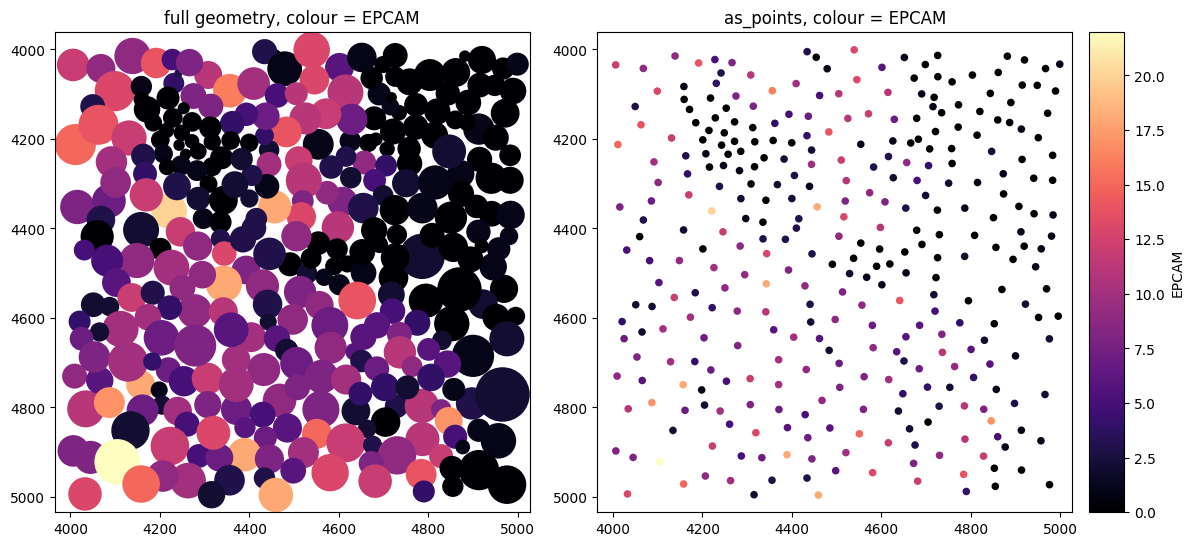

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
# Both panels share the same EPCAM scale, so we draw a single colourbar (right).
crop.pl.render_shapes("cell_circles", color="EPCAM", cmap="magma", colorbar=False).pl.show(
    ax=axes[0], title="full geometry, colour = EPCAM"
)
crop.pl.render_shapes(
    "cell_circles", color="EPCAM", cmap="magma", as_points=True, size=30
).pl.show(ax=axes[1], title="as_points, colour = EPCAM")
fig.tight_layout()

`size` sets the marker area (matplotlib's scatter `s`), independent of the data.
It is a styling choice, not the cell's real size, which the centroid view does
not carry. Larger markers read better when zoomed out; smaller ones keep dense
regions from overlapping into a blob.

The default is `size=1.0`, deliberately tiny so that dense point sets do not merge
into a blob; you will usually raise it, as every example here does.

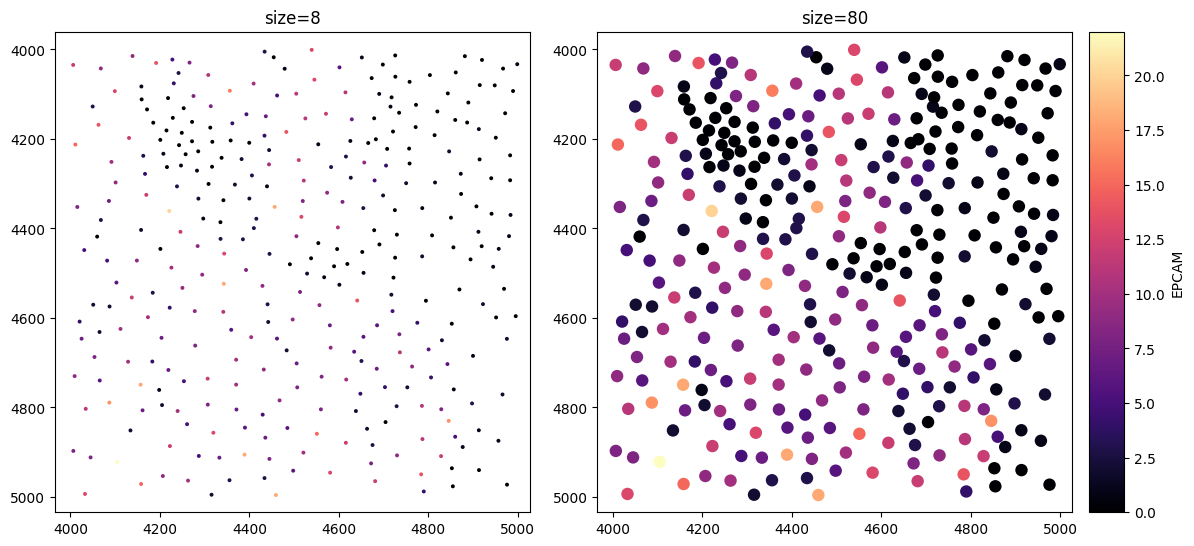

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
crop.pl.render_shapes(
    "cell_circles", color="EPCAM", cmap="magma", as_points=True, size=8, colorbar=False
).pl.show(ax=axes[0], title="size=8")
crop.pl.render_shapes(
    "cell_circles", color="EPCAM", cmap="magma", as_points=True, size=80
).pl.show(ax=axes[1], title="size=80")
fig.tight_layout()

## 3. Labels: segmentation masks as centroids

Xenium has no labels element, so we build one from the real cell boundaries.
`rasterize(..., return_regions_as_labels=True)` paints each cell's polygon with
its integer id, producing a segmentation mask whose pixel value is the cell id.

`render_labels(..., as_points=True)` then draws one dot per label. The centroids
come from the rendered, display-resolution raster, so the computation stays
cheap. `contour_px` and the outline options are ignored.

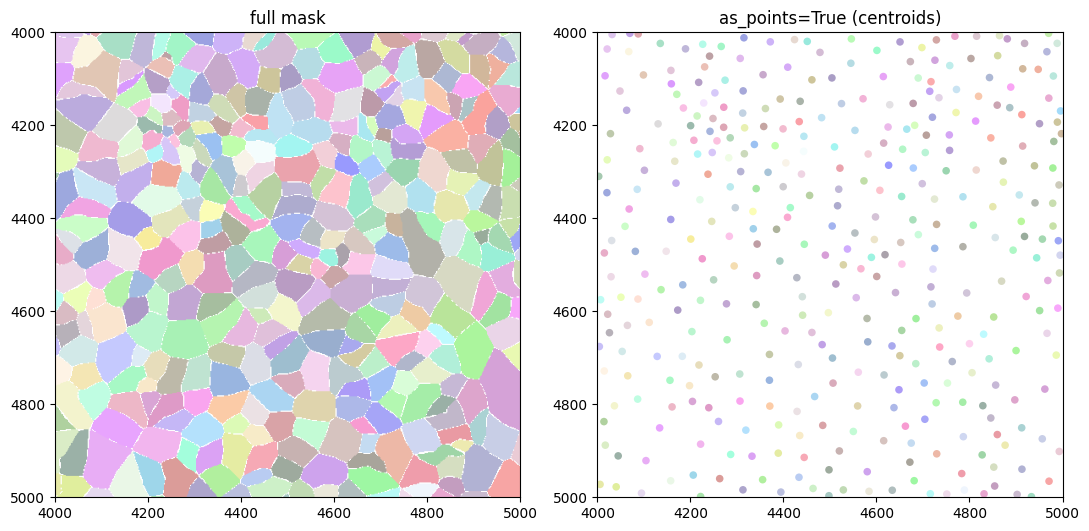

In [5]:
cell_masks = rasterize(
    crop["cell_boundaries"],
    ["x", "y"],
    min_coordinate=[XMIN, YMIN],
    max_coordinate=[XMAX, YMAX],
    target_coordinate_system="global",
    target_unit_to_pixels=1.0,
    return_regions_as_labels=True,
)
crop["cell_masks"] = cell_masks

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
crop.pl.render_labels("cell_masks").pl.show(ax=axes[0], title="full mask")
crop.pl.render_labels("cell_masks", as_points=True, size=30).pl.show(
    ax=axes[1], title="as_points=True (centroids)"
)
fig.tight_layout()

## 4. The speed trade-off

`as_points` exists mainly for speed. We subsample the real cells across a range
of counts, up to the full 167780, and time each render. The backend is held at
matplotlib, so the comparison is drawing N polygons or masks against drawing N
dots.

In [6]:
def time_best(fn, repeat=3):
    # Best wall-clock of `repeat` runs, closing figures between them.
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        plt.close("all")
        best = min(best, time.perf_counter() - t0)
    return best

In [7]:
# Shapes: draw N circles against N centroid dots, up to every cell in the section.
circ = sdata["cell_circles"]
shape_ns = [1_000, 5_000, 20_000, 50_000, 100_000, len(circ)]
shape_full, shape_pts = [], []
for n in shape_ns:
    s = SpatialData(shapes={"c": circ.iloc[:n].copy()})
    shape_full.append(time_best(lambda: s.pl.render_shapes("c", method="matplotlib").pl.show()))  # noqa: B023
    shape_pts.append(
        time_best(lambda: s.pl.render_shapes("c", as_points=True, method="matplotlib").pl.show())  # noqa: B023
    )
    print(f"N={n:>7}:  full {shape_full[-1]:6.2f}s   as_points {shape_pts[-1]:5.2f}s   "
          f"({shape_full[-1] / shape_pts[-1]:.0f}x)")

N=   1000:  full   0.03s   as_points  0.01s   (4x)


N=   5000:  full   0.14s   as_points  0.02s   (9x)


N=  20000:  full   0.51s   as_points  0.04s   (13x)


N=  50000:  full   1.29s   as_points  0.09s   (14x)


N= 100000:  full   2.53s   as_points  0.16s   (15x)


N= 167780:  full   4.31s   as_points  0.27s   (16x)


In [8]:
# Labels: draw the filled mask against N centroid dots. We rasterize progressively
# larger crops to grow the cell count.
label_sides = [1_000, 4_000, 8_000, 12_000]
x0, y0 = 2_000, 2_000
label_ns, label_full, label_pts = [], [], []
for side in label_sides:
    cb = bounding_box_query(
        sdata["cell_boundaries"],
        min_coordinate=[x0, y0],
        max_coordinate=[x0 + side, y0 + side],
        axes=("x", "y"),
        target_coordinate_system="global",
    )
    m = rasterize(
        cb, ["x", "y"],
        min_coordinate=[x0, y0], max_coordinate=[x0 + side, y0 + side],
        target_coordinate_system="global", target_unit_to_pixels=1.0,
        return_regions_as_labels=True,
    )
    s = SpatialData(labels={"m": m})
    label_ns.append(len(cb))
    label_full.append(time_best(lambda: s.pl.render_labels("m").pl.show()))  # noqa: B023
    label_pts.append(
        time_best(lambda: s.pl.render_labels("m", as_points=True, method="matplotlib").pl.show())  # noqa: B023
    )
    print(f"N={len(cb):>6}:  full mask {label_full[-1]:5.2f}s   as_points {label_pts[-1]:5.2f}s")

N=   424:  full mask  0.10s   as_points  0.09s


N=  5833:  full mask  0.11s   as_points  0.10s


N= 18606:  full mask  0.12s   as_points  0.12s


N= 39125:  full mask  0.17s   as_points  0.15s


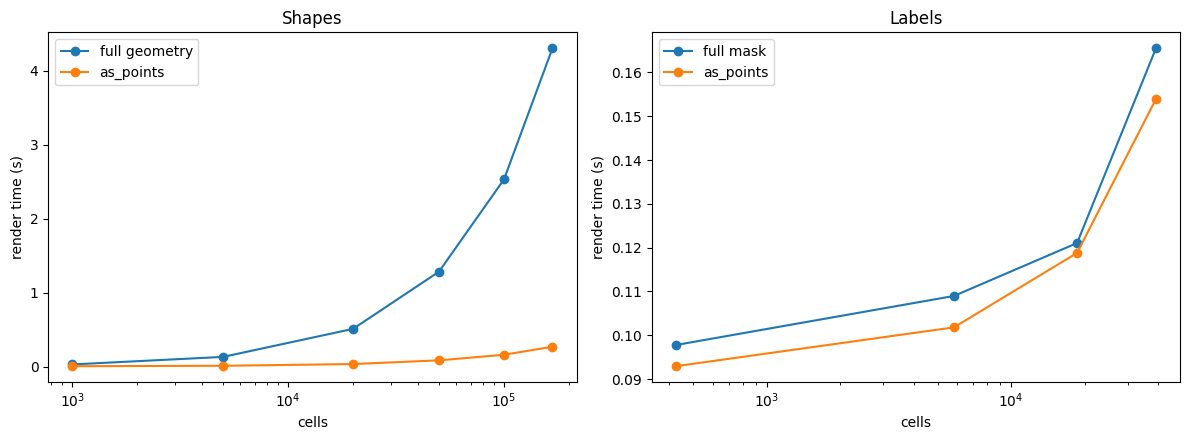

In [9]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))

axL.plot(shape_ns, shape_full, "o-", label="full geometry")
axL.plot(shape_ns, shape_pts, "o-", label="as_points")
axL.set(title="Shapes", xlabel="cells", ylabel="render time (s)")
axL.set_xscale("log")
axL.legend()

axR.plot(label_ns, label_full, "o-", label="full mask")
axR.plot(label_ns, label_pts, "o-", label="as_points")
axR.set(title="Labels", xlabel="cells", ylabel="render time (s)")
axR.set_xscale("log")
axR.legend()

fig.tight_layout()

The two panels behave differently:

- Shapes: a large gain that grows with cell count. Each circle is a vector
  primitive matplotlib draws one at a time, while a centroid is a single scatter
  point. At the full section (167780 cells) `as_points` is roughly 15 times
  faster.
- Labels: about the same either way. A labels element renders as a raster (an
  `imshow` downsampled to the display), whose cost tracks display pixels rather
  than cell count, and computing centroids costs about as much. For labels,
  `as_points` gives a different look, not a speedup.

Use `as_points` on shapes when you have many objects and do not need their
morphology. Use it on labels when you want the centroid representation.

## 5. Backend and the 50000 rule

**datashader** is a library that renders very large point sets by aggregating them
into a pixel grid instead of drawing each dot individually; `spatialdata-plot` uses
it as an optional backend. The dots can be drawn by either backend, set with `method`:

- `method="matplotlib"`: per-glyph scatter, exact, good up to tens of thousands
  of dots.
- `method="datashader"`: density raster, scales to millions.
- `method=None` (default): matplotlib, switching to datashader above 50000
  centroids (`AS_POINTS_DS_AUTO = 50000`), because matplotlib's per-glyph cost
  starts to dominate around there.

datashader aggregates and then shades, so it cannot represent one distinct random
colour per cell, which is the default colouring of a labels element with no
colour column. In that case it falls back to matplotlib with a warning. With a
real colour column, as below, both backends work and differ only in appearance.

As in section 2, the single colourbar below is valid only because both panels map the
same values; pass an explicit `norm` to guarantee a shared scale otherwise.

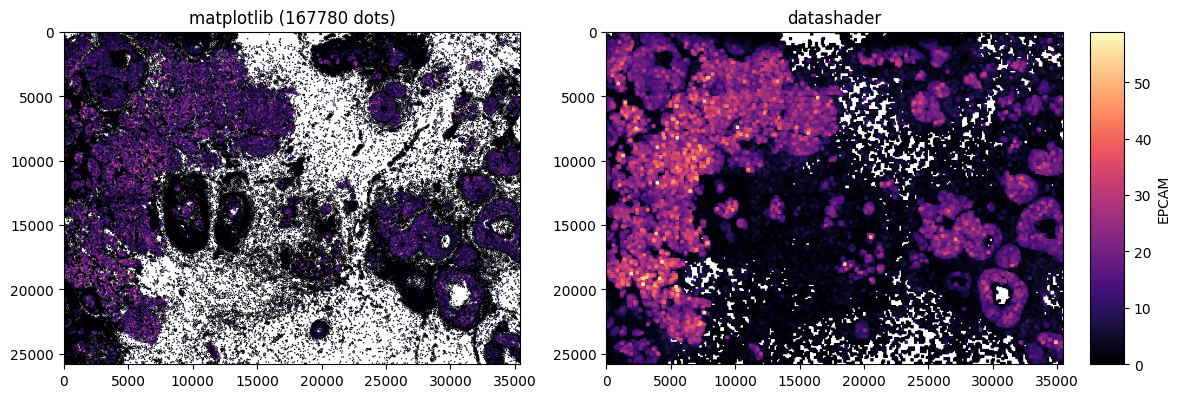

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
# Shared EPCAM scale, so the colourbar is drawn once on the right panel.
sdata.pl.render_shapes(
    "cell_circles", color="EPCAM", cmap="magma", as_points=True, method="matplotlib", colorbar=False
).pl.show(ax=axes[0], title="matplotlib (167780 dots)")
sdata.pl.render_shapes(
    "cell_circles", color="EPCAM", cmap="magma", as_points=True, method="datashader"
).pl.show(ax=axes[1], title="datashader")
fig.tight_layout()

## When to reach for `as_points`

- Many shapes, morphology not needed: a fast overview of hundreds of thousands of
  cells coloured by a value, without waiting on polygon drawing.
- Positions over an image: dots read more clearly than filled masks on top of
  tissue.
- Not for label speed: rendering a mask is already fast, so use `as_points` on
  labels only for the dot look.
- Remember what is dropped: the cell's real size, outline and shape. The marker
  `size` is a styling value, not the cell's area. When those properties carry
  meaning, keep the full geometry.

## For reproducibility

In [11]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import spatialdata_plot

%load_ext watermark
# fmt: on
%watermark -v -m -p spatialdata,spatialdata_plot,matplotlib,numpy,datashader,pooch

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
matplotlib      : 3.10.9
numpy           : 2.4.4
datashader      : 0.19.0
pooch           : 1.9.0

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

